### Se importan librerias

In [161]:
#General
import numpy as np
import pandas as pd
from scipy.stats import uniform
import os
from skimpy import skim
from tqdm import tqdm

#Graficas
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from pandas.plotting import andrews_curves

#Valores atipicos
from pyod.models.mcd import MCD
from pyod.models.iforest import IForest

#Codificadores
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder

#Busqueda de hiper-parametros, train test, metricas
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score, train_test_split
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score, roc_curve, confusion_matrix, make_scorer

#Modelo de clasificación
from sklearn.svm import SVC

#Escaladores
from sklearn.preprocessing import RobustScaler

### Carga de Archivo

In [88]:
path_file = "../data/Incendios_forestales.csv"

In [89]:
df = pd.read_csv(path_file)

In [90]:
df.head()

,anio,Clave_del_incendio,latitud,longitud,Clave_Municipio,Estado,Municipio,CVE_ENT,CVE_MUN,CVEGEO,...,Entidad,fn_Clave_del_incendio,fn_Predio,fn_Causa,fn_Causa_especifica,fn_Duracion_dias,fn_Tipo_de_incendio,fn_Tipo_Vegetacion,fn_Tipo_impacto,fn_Tamano
0,2022,22-01-0001,21.997253,-102.230097,11,Aguascalientes,San Francisco de los Romo,1,11,1101,...,Aguascalientes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2022,22-01-0002,21.694700,-102.265758,1,Aguascalientes,Aguascalientes,1,1,101,...,Aguascalientes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2022,22-01-0003,21.686344,-102.274769,1,Aguascalientes,Aguascalientes,1,1,101,...,Aguascalientes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2022,22-01-0004,21.837694,-102.247233,1,Aguascalientes,Aguascalientes,1,1,101,...,Aguascalientes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2022,22-01-0005,21.752181,-102.480086,1,Aguascalientes,Aguascalientes,1,1,101,...,Aguascalientes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [91]:
#Transformamos en categorica
df["Clave_del_incendio"] = df["Clave_del_incendio"].astype("category")
df["Estado"] = df["Estado"].astype("category")
df["Municipio"] = df["Municipio"].astype("category")
df["Region"] = df["Region"].astype("category")
df["Predio"] = df["Predio"].astype("category")
df["Causa"] = df["Causa"].astype("category")
df["Causa_especifica"] = df["Causa_especifica"].astype("category")
df["Fecha_Inicio"] = df["Fecha_Inicio"].astype("category")
df["Fecha_Termino"] = df["Fecha_Termino"].astype("category")
df["Duracion_dias"] = df["Duracion_dias"].astype("category")
df["Tipo_de_incendio"] = df["Tipo_de_incendio"].astype("category")
df["Tipo_Vegetacion"] = df["Tipo_Vegetacion"].astype("category")
df["Regimen_de_fuego"] = df["Regimen_de_fuego"].astype("category")
df["Tipo_impacto"] = df["Tipo_impacto"].astype("category")
df["Tamano"] = df["Tamano"].astype("category")
df["Entidad"] = df["Entidad"].astype("category")
df["fn_Clave_del_incendio"] = df["fn_Clave_del_incendio"].astype("category")

In [92]:
#skim(df)

1. Podemos ver que tenemos 8 variables que se encuentran nulas completamente, por lo que no aportan información, pareciera que en algún momento se intetó hacer alguna función de las variables originales pero no se les aplicó formula alguna, por lo que se decide borrar esas columnas.

2. De igual forma la variable **fn_Clave_del_incendio** tiene un 96% de valores nulos, al compararlo con la variable **Clave_del_incendio** nos podemos percatar que los valores que no son nulos, son iguales a los de esta variable, por lo que no vale la pena conervar esta variable, y se decide eliminar.

3. También podemos ver que la variable **Predio** no se repite tantas veces, por lo que no nos conviene conservar dicha variable y se decide eliminar.

4. De igual forma debemos eliminar las variables de fecha debido a que no se trabajará con series de tiempo por lo que no tendrá relevancia.

5. Eliminado de variable **CVE_MUN** debido a que es igual a la variable **Clave_Municipio**.

6. Eliminar variable **Clave_del_incendio** ya que es un identificador que no aporta valor alguno, ya que cada valor es diferente.

### Valores nulos

1. Eliminado de variables fn.

In [93]:
df2 = df.drop(['fn_Predio', 'fn_Causa', 'fn_Causa_especifica', 'fn_Duracion_dias', 'fn_Tipo_de_incendio', 'fn_Tipo_Vegetacion', 'fn_Tipo_impacto', 'fn_Tamano'], axis=1)

In [94]:
df2.head()

,anio,Clave_del_incendio,latitud,longitud,Clave_Municipio,Estado,Municipio,CVE_ENT,CVE_MUN,CVEGEO,...,Arbustivo,Herbaceo,Hojarasca,Total_hectareas,Tamano,Deteccion,Llegada,Duracion,Entidad,fn_Clave_del_incendio
0,2022,22-01-0001,21.997253,-102.230097,11,Aguascalientes,San Francisco de los Romo,1,11,1101,...,9.06330,51.35820,0.0,60.4215,51 a 100 Hectáreas,2700,4500,25200,Aguascalientes,NaN
1,2022,22-01-0002,21.694700,-102.265758,1,Aguascalientes,Aguascalientes,1,1,101,...,1.31100,24.90900,0.0,26.2200,21 a 50 Hectáreas,4500,5400,19800,Aguascalientes,NaN
2,2022,22-01-0003,21.686344,-102.274769,1,Aguascalientes,Aguascalientes,1,1,101,...,2.12500,40.37500,0.0,42.5000,21 a 50 Hectáreas,4500,5400,22500,Aguascalientes,NaN
3,2022,22-01-0004,21.837694,-102.247233,1,Aguascalientes,Aguascalientes,1,1,101,...,0.46600,8.85400,0.0,9.3200,6 a 10 Hectáreas,600,1500,20400,Aguascalientes,NaN
4,2022,22-01-0005,21.752181,-102.480086,1,Aguascalientes,Aguascalientes,1,1,101,...,5.65729,50.91561,0.0,56.5729,51 a 100 Hectáreas,2100,6000,19800,Aguascalientes,NaN


2. Eliminado de variable **fn_Clave_del_incendio** con valores duplicados.

In [95]:
# 1. Filtrar valores no nulos de fn_Clave_del_incendio
fn_vals = df2['fn_Clave_del_incendio'].dropna()

# 2. Normalizar: quitar ".0" si provienen de floats convertidos a string
fn_vals_norm = fn_vals.astype(str).str.replace(r'\.0$', '', regex=True).str.strip()

# 3. Normalizar también Clave_del_incendio
clave_vals_norm = df2['Clave_del_incendio'].astype(str).str.strip()

# 4. Verificar inclusión: ¿todos los valores de fn están en Clave?
todos_existen = fn_vals_norm.isin(clave_vals_norm).all()

print("¿Todos los valores de fn_Clave_del_incendio existen en Clave_del_incendio?:", todos_existen)

# 5. (Opcional) Mostrar si hay algún valor de fn que no esté en Clave
faltantes = fn_vals_norm[~fn_vals_norm.isin(clave_vals_norm)].unique()
print("Valores de fn que no aparecen en Clave:", faltantes)

¿Todos los valores de fn_Clave_del_incendio existen en Clave_del_incendio?: True
Valores de fn que no aparecen en Clave: []


In [96]:
df2.drop('fn_Clave_del_incendio', axis=1, inplace=True)

In [97]:
df2.head()

,anio,Clave_del_incendio,latitud,longitud,Clave_Municipio,Estado,Municipio,CVE_ENT,CVE_MUN,CVEGEO,...,Renuevo,Arbustivo,Herbaceo,Hojarasca,Total_hectareas,Tamano,Deteccion,Llegada,Duracion,Entidad
0,2022,22-01-0001,21.997253,-102.230097,11,Aguascalientes,San Francisco de los Romo,1,11,1101,...,0.0,9.06330,51.35820,0.0,60.4215,51 a 100 Hectáreas,2700,4500,25200,Aguascalientes
1,2022,22-01-0002,21.694700,-102.265758,1,Aguascalientes,Aguascalientes,1,1,101,...,0.0,1.31100,24.90900,0.0,26.2200,21 a 50 Hectáreas,4500,5400,19800,Aguascalientes
2,2022,22-01-0003,21.686344,-102.274769,1,Aguascalientes,Aguascalientes,1,1,101,...,0.0,2.12500,40.37500,0.0,42.5000,21 a 50 Hectáreas,4500,5400,22500,Aguascalientes
3,2022,22-01-0004,21.837694,-102.247233,1,Aguascalientes,Aguascalientes,1,1,101,...,0.0,0.46600,8.85400,0.0,9.3200,6 a 10 Hectáreas,600,1500,20400,Aguascalientes
4,2022,22-01-0005,21.752181,-102.480086,1,Aguascalientes,Aguascalientes,1,1,101,...,0.0,5.65729,50.91561,0.0,56.5729,51 a 100 Hectáreas,2100,6000,19800,Aguascalientes


3. Eliminado de variable **Predio**

In [98]:
df2 = df2.drop(['Predio'], axis=1)

In [99]:
df2.head()

,anio,Clave_del_incendio,latitud,longitud,Clave_Municipio,Estado,Municipio,CVE_ENT,CVE_MUN,CVEGEO,...,Renuevo,Arbustivo,Herbaceo,Hojarasca,Total_hectareas,Tamano,Deteccion,Llegada,Duracion,Entidad
0,2022,22-01-0001,21.997253,-102.230097,11,Aguascalientes,San Francisco de los Romo,1,11,1101,...,0.0,9.06330,51.35820,0.0,60.4215,51 a 100 Hectáreas,2700,4500,25200,Aguascalientes
1,2022,22-01-0002,21.694700,-102.265758,1,Aguascalientes,Aguascalientes,1,1,101,...,0.0,1.31100,24.90900,0.0,26.2200,21 a 50 Hectáreas,4500,5400,19800,Aguascalientes
2,2022,22-01-0003,21.686344,-102.274769,1,Aguascalientes,Aguascalientes,1,1,101,...,0.0,2.12500,40.37500,0.0,42.5000,21 a 50 Hectáreas,4500,5400,22500,Aguascalientes
3,2022,22-01-0004,21.837694,-102.247233,1,Aguascalientes,Aguascalientes,1,1,101,...,0.0,0.46600,8.85400,0.0,9.3200,6 a 10 Hectáreas,600,1500,20400,Aguascalientes
4,2022,22-01-0005,21.752181,-102.480086,1,Aguascalientes,Aguascalientes,1,1,101,...,0.0,5.65729,50.91561,0.0,56.5729,51 a 100 Hectáreas,2100,6000,19800,Aguascalientes


4. Eliminado de variables fecha

In [100]:
df2 = df2.drop(['Fecha_Inicio', 'Fecha_Termino'], axis=1)

In [101]:
df2.head()

,anio,Clave_del_incendio,latitud,longitud,Clave_Municipio,Estado,Municipio,CVE_ENT,CVE_MUN,CVEGEO,...,Renuevo,Arbustivo,Herbaceo,Hojarasca,Total_hectareas,Tamano,Deteccion,Llegada,Duracion,Entidad
0,2022,22-01-0001,21.997253,-102.230097,11,Aguascalientes,San Francisco de los Romo,1,11,1101,...,0.0,9.06330,51.35820,0.0,60.4215,51 a 100 Hectáreas,2700,4500,25200,Aguascalientes
1,2022,22-01-0002,21.694700,-102.265758,1,Aguascalientes,Aguascalientes,1,1,101,...,0.0,1.31100,24.90900,0.0,26.2200,21 a 50 Hectáreas,4500,5400,19800,Aguascalientes
2,2022,22-01-0003,21.686344,-102.274769,1,Aguascalientes,Aguascalientes,1,1,101,...,0.0,2.12500,40.37500,0.0,42.5000,21 a 50 Hectáreas,4500,5400,22500,Aguascalientes
3,2022,22-01-0004,21.837694,-102.247233,1,Aguascalientes,Aguascalientes,1,1,101,...,0.0,0.46600,8.85400,0.0,9.3200,6 a 10 Hectáreas,600,1500,20400,Aguascalientes
4,2022,22-01-0005,21.752181,-102.480086,1,Aguascalientes,Aguascalientes,1,1,101,...,0.0,5.65729,50.91561,0.0,56.5729,51 a 100 Hectáreas,2100,6000,19800,Aguascalientes


5. Eliminado de variable duplicada **clave municipio**

In [102]:
(df2['CVE_MUN'] == df2['Clave_Municipio']).all()

np.True_

In [103]:
df2 = df2.drop(['CVE_MUN'], axis=1)

In [104]:
df2.head()

,anio,Clave_del_incendio,latitud,longitud,Clave_Municipio,Estado,Municipio,CVE_ENT,CVEGEO,Region,...,Renuevo,Arbustivo,Herbaceo,Hojarasca,Total_hectareas,Tamano,Deteccion,Llegada,Duracion,Entidad
0,2022,22-01-0001,21.997253,-102.230097,11,Aguascalientes,San Francisco de los Romo,1,1101,Occidente,...,0.0,9.06330,51.35820,0.0,60.4215,51 a 100 Hectáreas,2700,4500,25200,Aguascalientes
1,2022,22-01-0002,21.694700,-102.265758,1,Aguascalientes,Aguascalientes,1,101,Occidente,...,0.0,1.31100,24.90900,0.0,26.2200,21 a 50 Hectáreas,4500,5400,19800,Aguascalientes
2,2022,22-01-0003,21.686344,-102.274769,1,Aguascalientes,Aguascalientes,1,101,Occidente,...,0.0,2.12500,40.37500,0.0,42.5000,21 a 50 Hectáreas,4500,5400,22500,Aguascalientes
3,2022,22-01-0004,21.837694,-102.247233,1,Aguascalientes,Aguascalientes,1,101,Occidente,...,0.0,0.46600,8.85400,0.0,9.3200,6 a 10 Hectáreas,600,1500,20400,Aguascalientes
4,2022,22-01-0005,21.752181,-102.480086,1,Aguascalientes,Aguascalientes,1,101,Occidente,...,0.0,5.65729,50.91561,0.0,56.5729,51 a 100 Hectáreas,2100,6000,19800,Aguascalientes


6. Eliminado de variable **Clave_del_incendio**

In [105]:
df2 = df2.drop(['Clave_del_incendio'], axis=1)

In [106]:
df2.head()

,anio,latitud,longitud,Clave_Municipio,Estado,Municipio,CVE_ENT,CVEGEO,Region,Causa,...,Renuevo,Arbustivo,Herbaceo,Hojarasca,Total_hectareas,Tamano,Deteccion,Llegada,Duracion,Entidad
0,2022,21.997253,-102.230097,11,Aguascalientes,San Francisco de los Romo,1,1101,Occidente,Actividades ilícitas,...,0.0,9.06330,51.35820,0.0,60.4215,51 a 100 Hectáreas,2700,4500,25200,Aguascalientes
1,2022,21.694700,-102.265758,1,Aguascalientes,Aguascalientes,1,101,Occidente,Actividades ilícitas,...,0.0,1.31100,24.90900,0.0,26.2200,21 a 50 Hectáreas,4500,5400,19800,Aguascalientes
2,2022,21.686344,-102.274769,1,Aguascalientes,Aguascalientes,1,101,Occidente,Actividades ilícitas,...,0.0,2.12500,40.37500,0.0,42.5000,21 a 50 Hectáreas,4500,5400,22500,Aguascalientes
3,2022,21.837694,-102.247233,1,Aguascalientes,Aguascalientes,1,101,Occidente,Actividades ilícitas,...,0.0,0.46600,8.85400,0.0,9.3200,6 a 10 Hectáreas,600,1500,20400,Aguascalientes
4,2022,21.752181,-102.480086,1,Aguascalientes,Aguascalientes,1,101,Occidente,Fumadores,...,0.0,5.65729,50.91561,0.0,56.5729,51 a 100 Hectáreas,2100,6000,19800,Aguascalientes


### Análisis exploratorio

In [107]:
var_cat = ["Estado", "Municipio", "Region", "Causa", "Causa_especifica", "Duracion_dias", "Tipo_de_incendio",
          "Tipo_Vegetacion", "Regimen_de_fuego", "Tipo_impacto", "Tamano", "Entidad"]

var_num = ["anio", "latitud", "longitud", "Clave_Municipio", "CVE_ENT", "CVEGEO", "Arbolado_Adulto", 
           "Renuevo", "Arbustivo", "Herbaceo", "Hojarasca", "Deteccion", "Llegada", "Duracion"]

# TARGET: "Total_hectareas"

In [108]:
#Definimos un objeto para graficar
class analyze:
    # Inicializamos la clase
    def __init__(self, df2, num_vars, cat_vars):
        self.df2 = df2
        self.num_vars = num_vars
        self.cat_vars = cat_vars

    #Método para graficar variables numéricas
    def plot_num(self):
        for var in self.num_vars:
            fig = make_subplots(rows=1, cols=2, subplot_titles=(f"{var} - Boxplot", f"{var} - Histograma"))

            # Boxplot
            fig.add_trace(
                go.Box(y=self.df2[var], name="Boxplot", marker_color="#008080"),
                row=1, col=1
            )

            # Histograma
            fig.add_trace(
                go.Histogram(x=self.df[var], name="Histograma",
                             marker_color="#00a77d", nbinsx=50,
                             histnorm='probability density'),
                row=1, col=2
            )

            fig.update_layout(title_text=f"Variable: {var}", height=400, width=800)
            fig.show()

    #Método para graficar variables categóricas
    def plot_cat(self):
        for var in self.cat_vars:
            value_counts = self.df2[var].value_counts()
            labels = value_counts.index.astype(str)
            values = value_counts.values

            fig = go.Figure(
                data=[go.Pie(labels=labels, values=values, textinfo='percent+label')]
            )

            fig.update_layout(title_text=f"Variable: {var}", height=400, width=500)
            fig.show()

    #Método para graficar la matriz de correlación de numéricas
    def corr_matrix(self):
        corr_matrix = self.df2[self.num_vars].corr()

        fig = go.Figure(data=go.Heatmap(
            z=corr_matrix.values,
            x=corr_matrix.columns,
            y=corr_matrix.columns,
            colorscale='Viridis'))

        fig.update_layout(
            title='Matriz de Correlación',
            width=800,
            height=600
        )

        fig.show()

In [109]:
#Curva de Andrews
def andrews_curve(df2, cat_col): 
    plt.figure(figsize=(12,8))
    andrews_curves(df2, cat_col, colormap='rainbow', alpha=0.6)
    plt.title('Curvas de Andrews')
    plt.xlabel('t (función de Fourier)')
    plt.ylabel('Valor transformado')
    plt.grid(True, color='lightgray', linestyle='--', linewidth=0.5)
    plt.show()

In [110]:
analisis = analyze(df2, var_num, var_cat)

In [ ]:
analisis.plot_num()

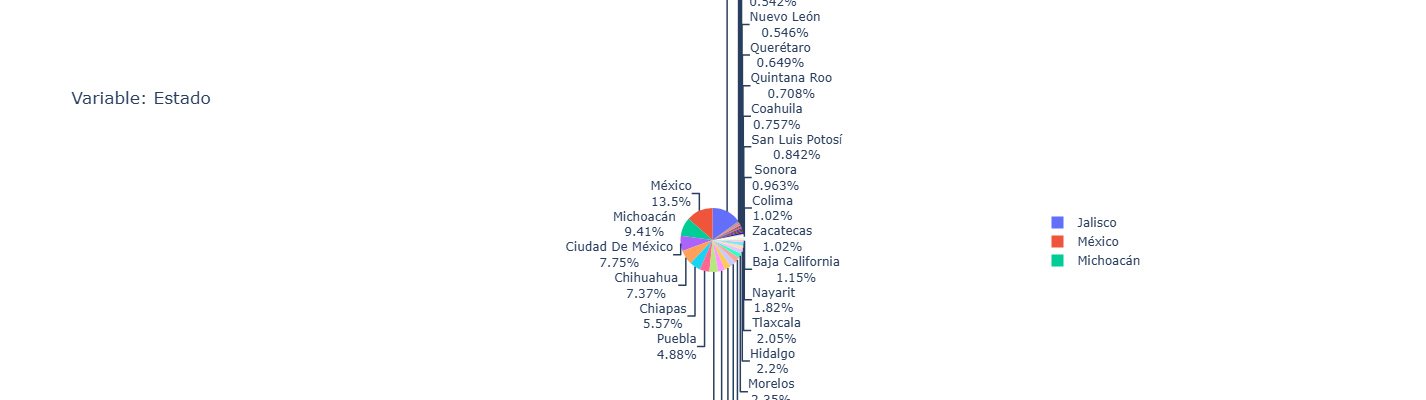

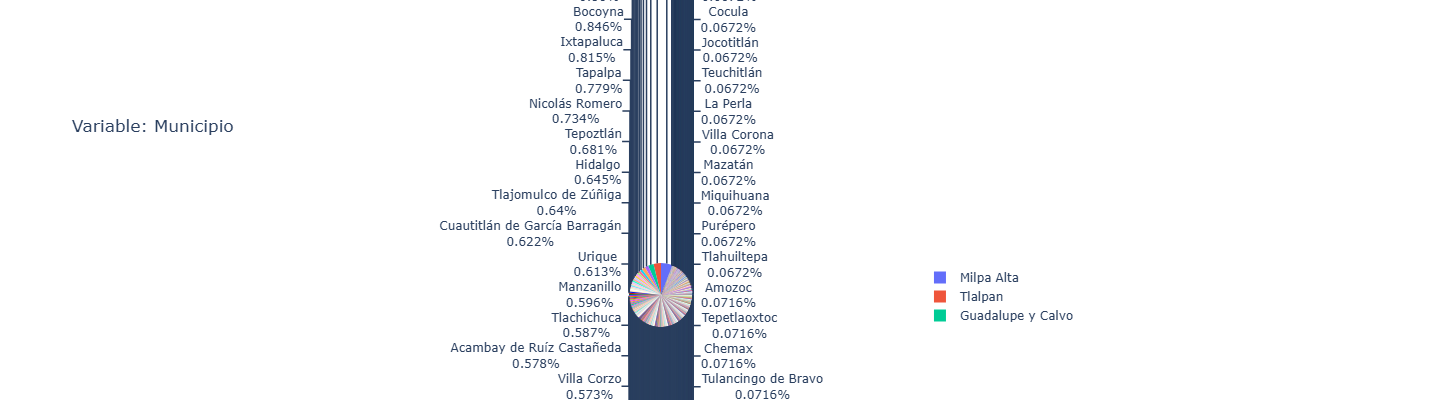

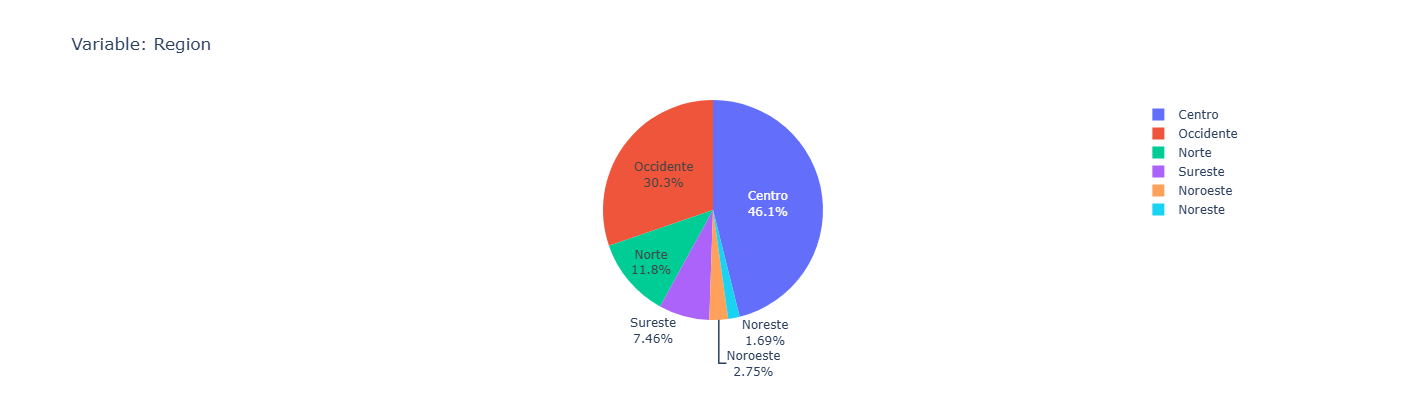

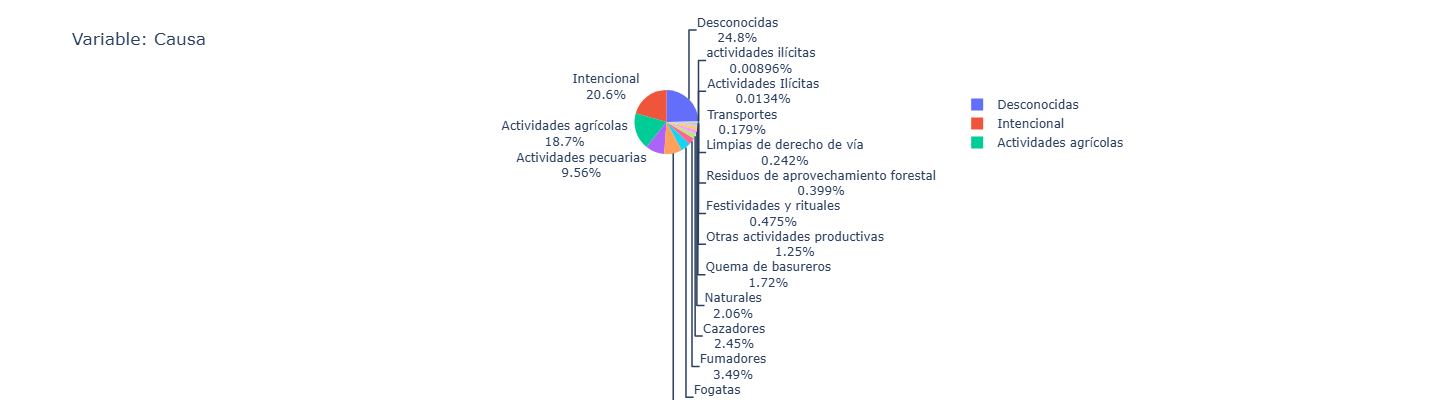

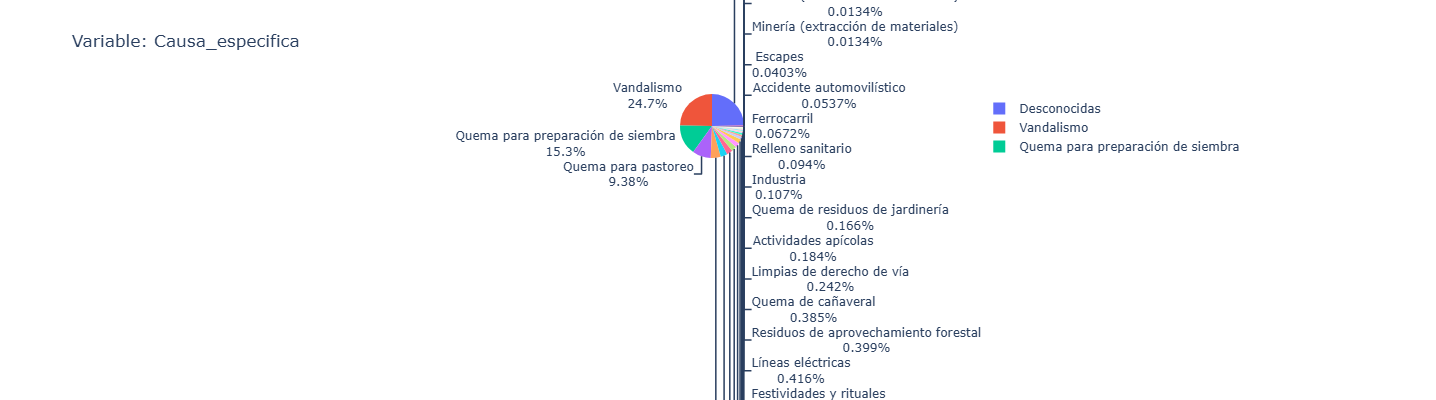

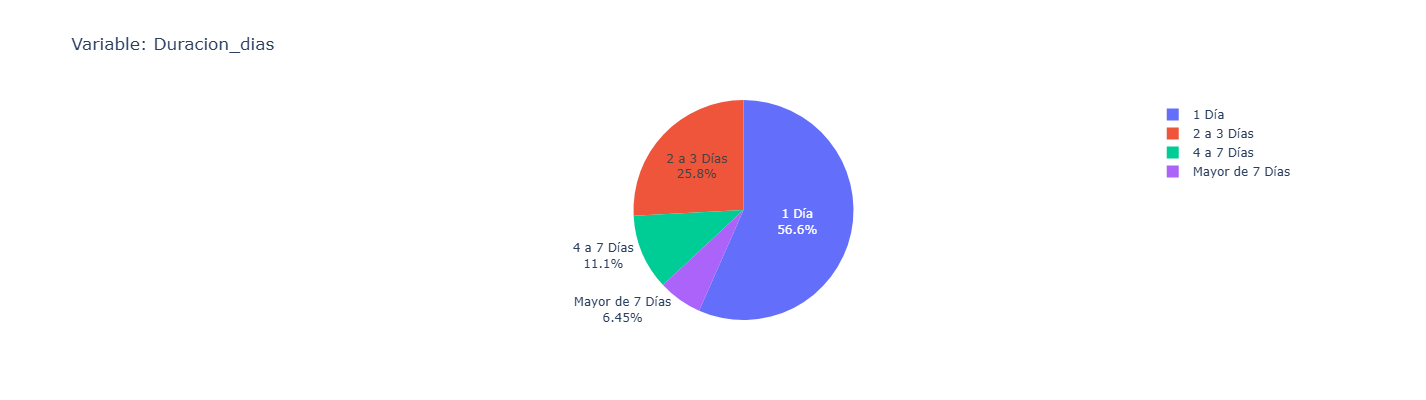

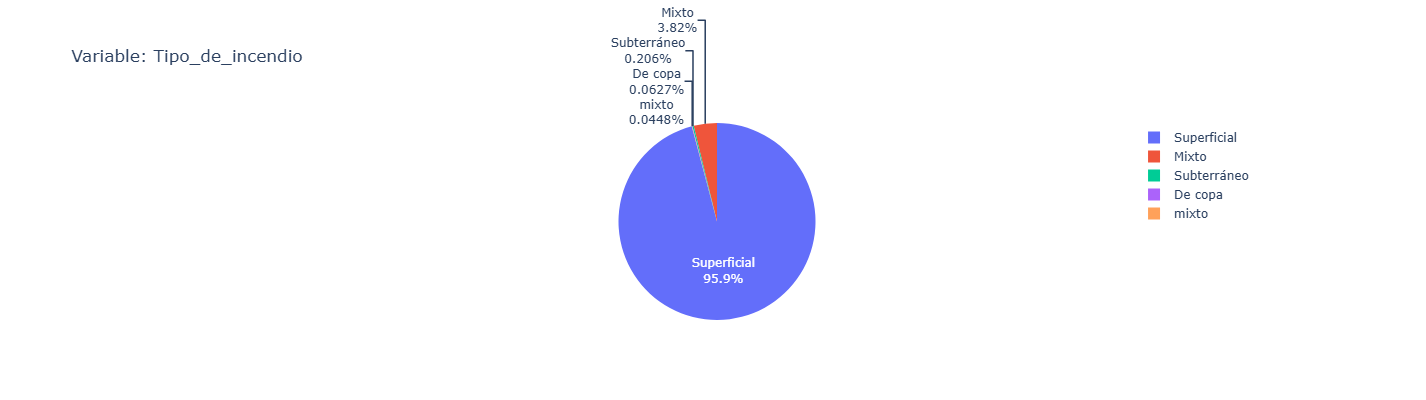

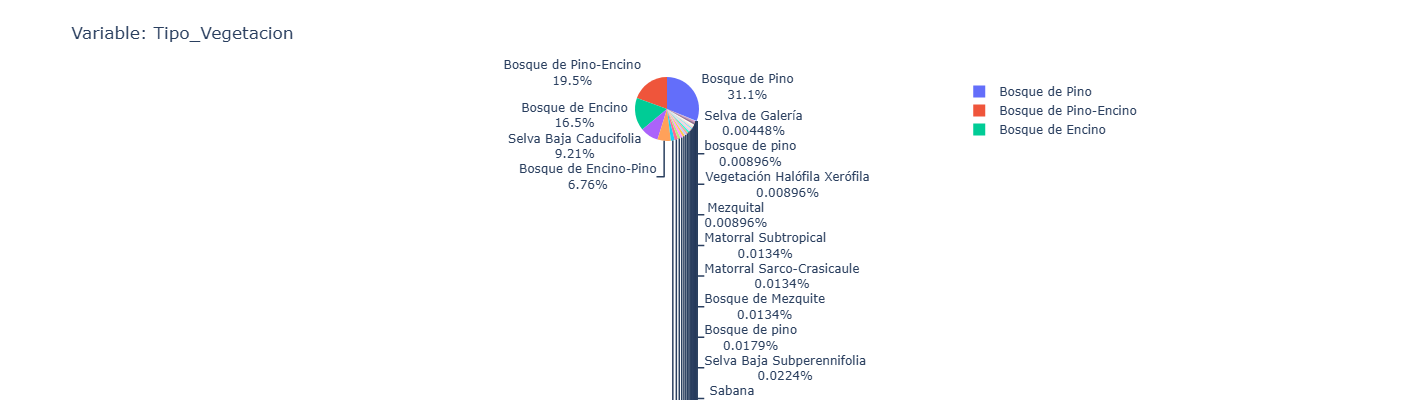

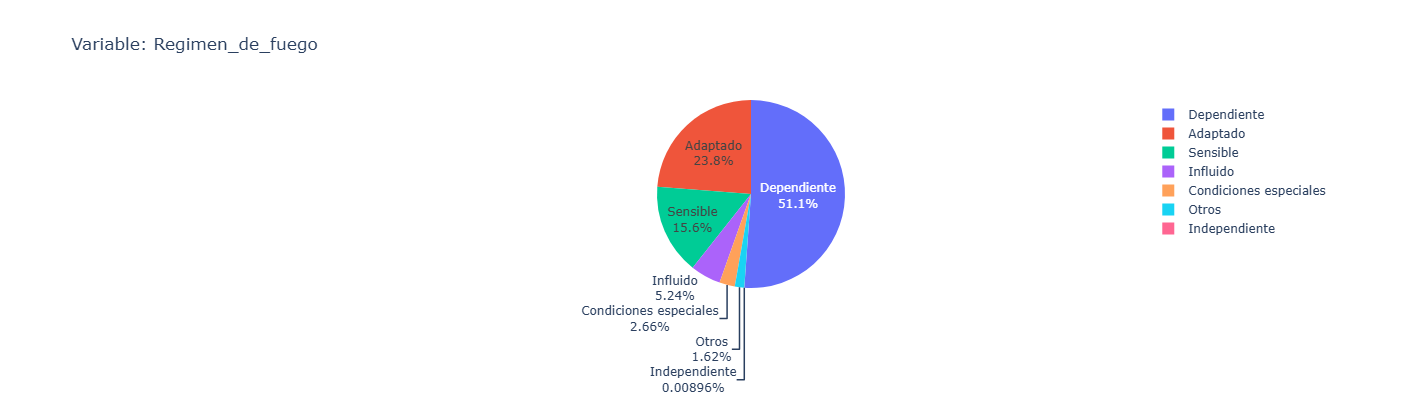

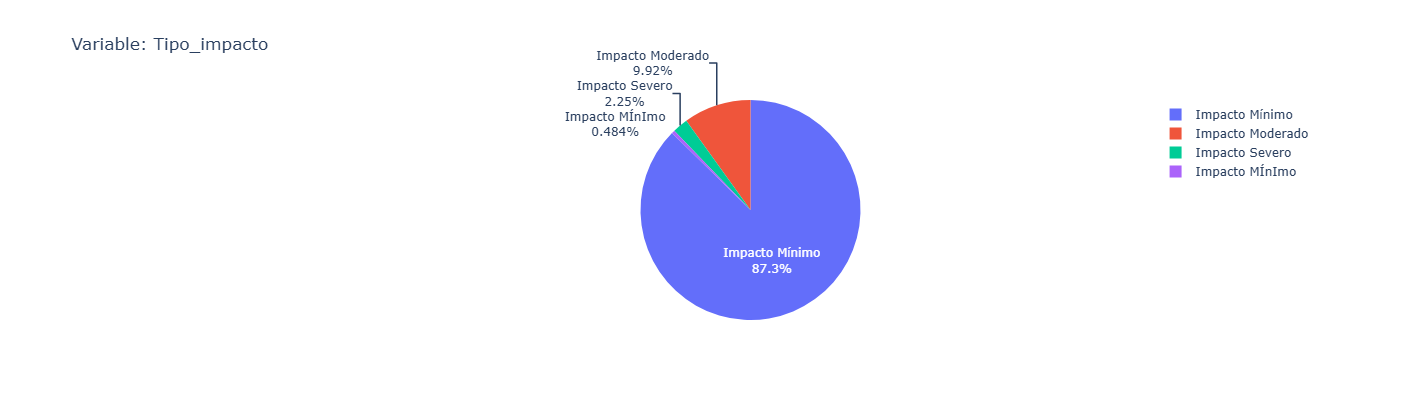

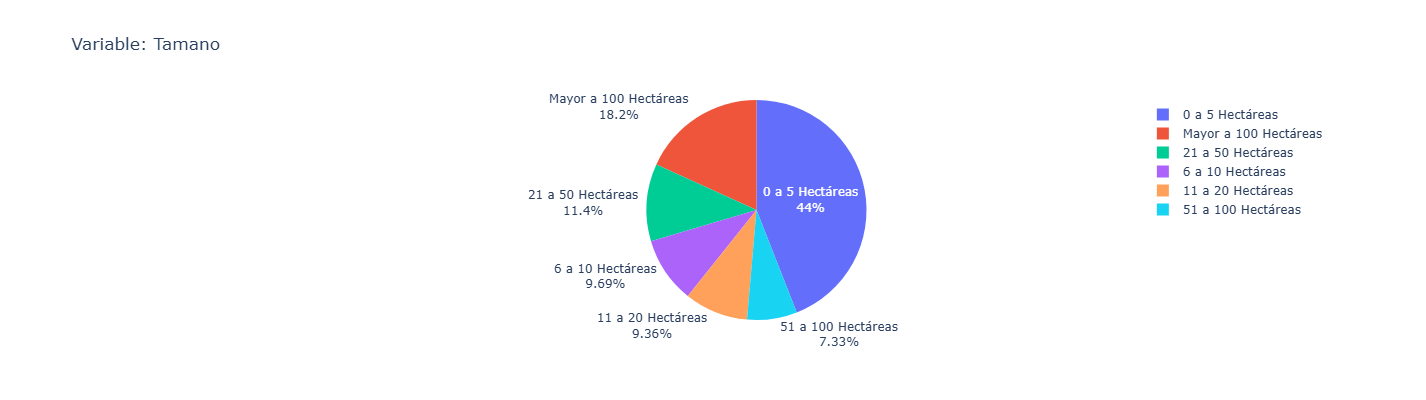

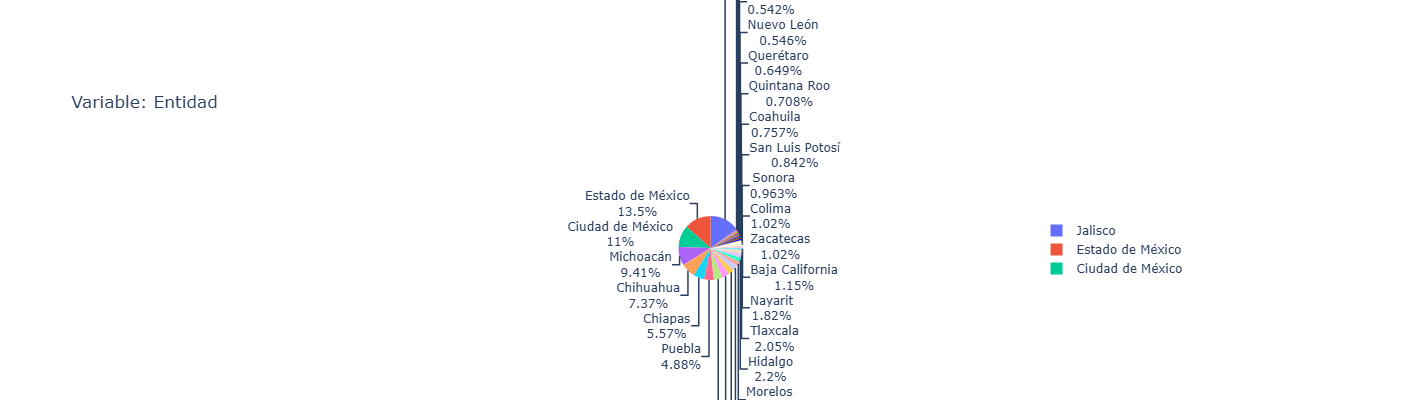

In [74]:
analisis.plot_cat()

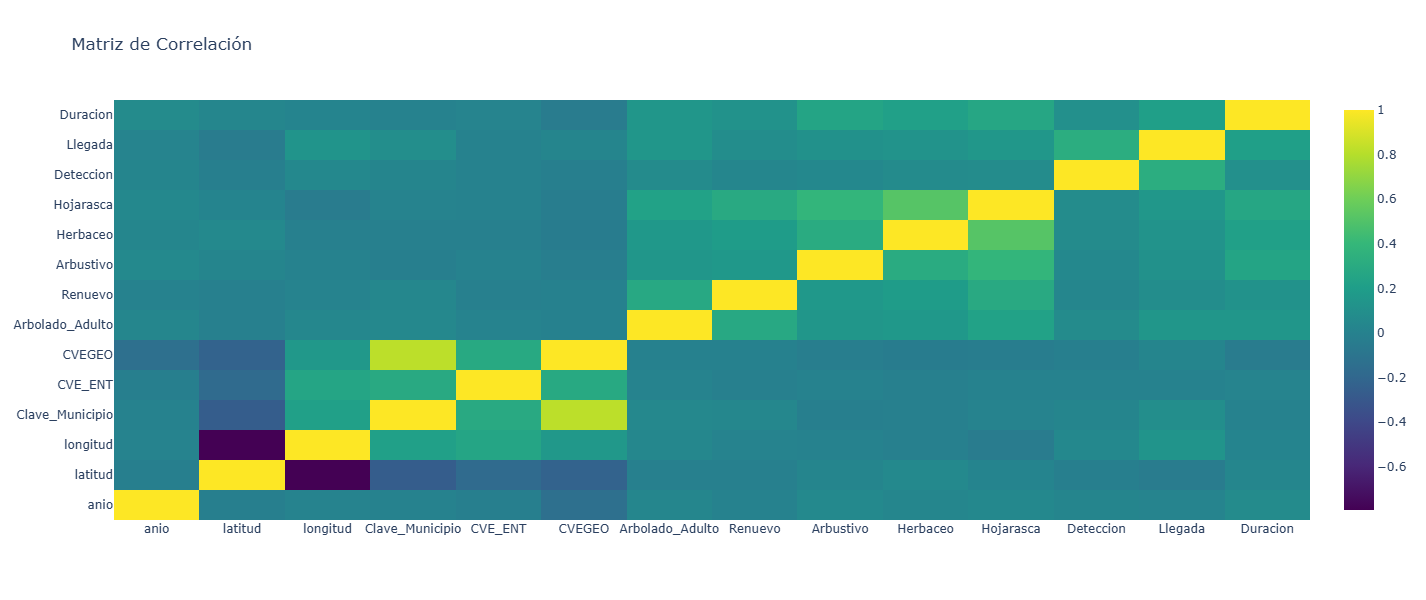

In [59]:
analisis.corr_matrix()

#### Valores atípicos

In [111]:
def outliers_iforest(df2, contamination=0.04, random_state=1989):
    model = IForest(contamination=contamination, random_state=random_state)
    model.fit(df2.values)
    preds = model.predict(df2.values)
    return df2[preds == 1]  # 1 = inliers, -1 = outliers

In [112]:
df_outliers = outliers_iforest(df2[var_num])

In [113]:
df_outliers

,anio,latitud,longitud,Clave_Municipio,CVE_ENT,CVEGEO,Arbolado_Adulto,Renuevo,Arbustivo,Herbaceo,Hojarasca,Deteccion,Llegada,Duracion
63,2022,31.523250,-115.550289,1,2,102,0.0000,0.0000,2502.8453,9.7428,0.00,1560,319200,1356000
66,2022,31.420494,-115.912425,1,2,102,12.9001,0.0000,414.3343,0.0000,0.00,900,174900,437400
79,2022,31.110150,-115.500842,1,2,102,45.8307,5.0923,203.6923,0.0000,0.00,8100,178200,2226000
83,2022,32.278208,-116.226147,3,2,302,38.0000,0.0000,493.7439,227.7000,0.00,1200,7200,352800
115,2022,18.485472,-89.228583,10,4,1004,0.0000,119.6095,0.0000,0.0000,0.00,64800,136800,255600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22277,2024,20.111822,-89.204956,79,31,7931,0.0000,0.0000,895.2800,0.0000,0.00,28680,37680,542580
22278,2024,20.752917,-90.235911,11,31,1131,0.0000,0.0000,500.1400,0.0000,0.00,10020,392400,1209600
22281,2024,21.286000,-87.695528,96,31,9631,0.0000,0.0000,635.0200,0.0000,0.00,70200,86400,181200
22289,2024,22.554608,-104.237681,49,32,4932,0.0000,0.0000,4.1600,178.6300,232.64,1800,684000,1044000


In [114]:
#Visualizamos en el df original
df2.loc[df_outliers.index]

,anio,latitud,longitud,Clave_Municipio,Estado,Municipio,CVE_ENT,CVEGEO,Region,Causa,...,Renuevo,Arbustivo,Herbaceo,Hojarasca,Total_hectareas,Tamano,Deteccion,Llegada,Duracion,Entidad
63,2022,31.523250,-115.550289,1,Baja California,Ensenada,2,102,Noroeste,Desconocidas,...,0.0000,2502.8453,9.7428,0.00,2512.5881,Mayor a 100 Hectáreas,1560,319200,1356000,Baja California
66,2022,31.420494,-115.912425,1,Baja California,Ensenada,2,102,Noroeste,Desconocidas,...,0.0000,414.3343,0.0000,0.00,427.2344,Mayor a 100 Hectáreas,900,174900,437400,Baja California
79,2022,31.110150,-115.500842,1,Baja California,Ensenada,2,102,Noroeste,Naturales,...,5.0923,203.6923,0.0000,0.00,254.6153,Mayor a 100 Hectáreas,8100,178200,2226000,Baja California
83,2022,32.278208,-116.226147,3,Baja California,Tecate,2,302,Noroeste,Desconocidas,...,0.0000,493.7439,227.7000,0.00,759.4439,Mayor a 100 Hectáreas,1200,7200,352800,Baja California
115,2022,18.485472,-89.228583,10,Campeche,Calakmul,4,1004,Sureste,Limpias de derecho de vía,...,119.6095,0.0000,0.0000,0.00,119.6095,Mayor a 100 Hectáreas,64800,136800,255600,Campeche
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22277,2024,20.111822,-89.204956,79,Yucatán,Tekax,31,7931,Sureste,Actividades agrícolas,...,0.0000,895.2800,0.0000,0.00,895.2800,Mayor a 100 Hectáreas,28680,37680,542580,Yucatán
22278,2024,20.752917,-90.235911,11,Yucatán,Celestún,31,1131,Sureste,Actividades pecuarias,...,0.0000,500.1400,0.0000,0.00,500.1400,Mayor a 100 Hectáreas,10020,392400,1209600,Yucatán
22281,2024,21.286000,-87.695528,96,Yucatán,Tizimín,31,9631,Sureste,Desconocidas,...,0.0000,635.0200,0.0000,0.00,635.0200,Mayor a 100 Hectáreas,70200,86400,181200,Yucatán
22289,2024,22.554608,-104.237681,49,Zacatecas,Valparaíso,32,4932,Occidente,Desconocidas,...,0.0000,4.1600,178.6300,232.64,415.4400,Mayor a 100 Hectáreas,1800,684000,1044000,Zacatecas


In [115]:
df_atipics = df2.drop(df_outliers.index)

In [116]:
df_atipics

,anio,latitud,longitud,Clave_Municipio,Estado,Municipio,CVE_ENT,CVEGEO,Region,Causa,...,Renuevo,Arbustivo,Herbaceo,Hojarasca,Total_hectareas,Tamano,Deteccion,Llegada,Duracion,Entidad
0,2022,21.997253,-102.230097,11,Aguascalientes,San Francisco de los Romo,1,1101,Occidente,Actividades ilícitas,...,0.0,9.06330,51.35820,0.00,60.4215,51 a 100 Hectáreas,2700,4500,25200,Aguascalientes
1,2022,21.694700,-102.265758,1,Aguascalientes,Aguascalientes,1,101,Occidente,Actividades ilícitas,...,0.0,1.31100,24.90900,0.00,26.2200,21 a 50 Hectáreas,4500,5400,19800,Aguascalientes
2,2022,21.686344,-102.274769,1,Aguascalientes,Aguascalientes,1,101,Occidente,Actividades ilícitas,...,0.0,2.12500,40.37500,0.00,42.5000,21 a 50 Hectáreas,4500,5400,22500,Aguascalientes
3,2022,21.837694,-102.247233,1,Aguascalientes,Aguascalientes,1,101,Occidente,Actividades ilícitas,...,0.0,0.46600,8.85400,0.00,9.3200,6 a 10 Hectáreas,600,1500,20400,Aguascalientes
4,2022,21.752181,-102.480086,1,Aguascalientes,Aguascalientes,1,101,Occidente,Fumadores,...,0.0,5.65729,50.91561,0.00,56.5729,51 a 100 Hectáreas,2100,6000,19800,Aguascalientes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22327,2024,22.097433,-103.134486,55,Zacatecas,Villanueva,32,5532,Occidente,Intencional,...,0.0,0.00000,20.79000,0.00,20.7900,11 a 20 Hectáreas,3600,0,34200,Zacatecas
22328,2024,22.765983,-104.225019,49,Zacatecas,Valparaíso,32,4932,Occidente,Fumadores,...,0.0,0.00000,0.00000,1.03,1.0300,0 a 5 Hectáreas,900,0,946800,Zacatecas
22329,2024,21.173661,-103.542964,11,Zacatecas,Trinidad García de la Cadena,32,1132,Occidente,Desconocidas,...,0.0,2.11000,7.78000,0.00,9.8900,6 a 10 Hectáreas,1200,0,79200,Zacatecas
22330,2024,22.781378,-102.580433,56,Zacatecas,Zacatecas,32,5632,Occidente,Desconocidas,...,0.0,0.00000,2.54000,0.00,2.5400,0 a 5 Hectáreas,720,1500,8700,Zacatecas


In [117]:
df_atipics.head()

,anio,latitud,longitud,Clave_Municipio,Estado,Municipio,CVE_ENT,CVEGEO,Region,Causa,...,Renuevo,Arbustivo,Herbaceo,Hojarasca,Total_hectareas,Tamano,Deteccion,Llegada,Duracion,Entidad
0,2022,21.997253,-102.230097,11,Aguascalientes,San Francisco de los Romo,1,1101,Occidente,Actividades ilícitas,...,0.0,9.06330,51.35820,0.0,60.4215,51 a 100 Hectáreas,2700,4500,25200,Aguascalientes
1,2022,21.694700,-102.265758,1,Aguascalientes,Aguascalientes,1,101,Occidente,Actividades ilícitas,...,0.0,1.31100,24.90900,0.0,26.2200,21 a 50 Hectáreas,4500,5400,19800,Aguascalientes
2,2022,21.686344,-102.274769,1,Aguascalientes,Aguascalientes,1,101,Occidente,Actividades ilícitas,...,0.0,2.12500,40.37500,0.0,42.5000,21 a 50 Hectáreas,4500,5400,22500,Aguascalientes
3,2022,21.837694,-102.247233,1,Aguascalientes,Aguascalientes,1,101,Occidente,Actividades ilícitas,...,0.0,0.46600,8.85400,0.0,9.3200,6 a 10 Hectáreas,600,1500,20400,Aguascalientes
4,2022,21.752181,-102.480086,1,Aguascalientes,Aguascalientes,1,101,Occidente,Fumadores,...,0.0,5.65729,50.91561,0.0,56.5729,51 a 100 Hectáreas,2100,6000,19800,Aguascalientes


#### Variables categóricas

Se decide eliminar las siguientes variables debido a que las absorbe muy bien la variable **Region**:

1. Estado
2. Municipio
3. Entidad

In [119]:
df_atipics = df_atipics.drop(['Estado', 'Municipio', 'Entidad'], axis=1)

In [120]:
df_atipics.head()

,anio,latitud,longitud,Clave_Municipio,CVE_ENT,CVEGEO,Region,Causa,Causa_especifica,Duracion_dias,...,Arbolado_Adulto,Renuevo,Arbustivo,Herbaceo,Hojarasca,Total_hectareas,Tamano,Deteccion,Llegada,Duracion
0,2022,21.997253,-102.230097,11,1,1101,Occidente,Actividades ilícitas,Vandalismo,1 Día,...,0.0,0.0,9.06330,51.35820,0.0,60.4215,51 a 100 Hectáreas,2700,4500,25200
1,2022,21.694700,-102.265758,1,1,101,Occidente,Actividades ilícitas,Vandalismo,1 Día,...,0.0,0.0,1.31100,24.90900,0.0,26.2200,21 a 50 Hectáreas,4500,5400,19800
2,2022,21.686344,-102.274769,1,1,101,Occidente,Actividades ilícitas,Vandalismo,1 Día,...,0.0,0.0,2.12500,40.37500,0.0,42.5000,21 a 50 Hectáreas,4500,5400,22500
3,2022,21.837694,-102.247233,1,1,101,Occidente,Actividades ilícitas,Vandalismo,1 Día,...,0.0,0.0,0.46600,8.85400,0.0,9.3200,6 a 10 Hectáreas,600,1500,20400
4,2022,21.752181,-102.480086,1,1,101,Occidente,Fumadores,Fumadores,1 Día,...,0.0,0.0,5.65729,50.91561,0.0,56.5729,51 a 100 Hectáreas,2100,6000,19800


Se decide eliminar la variable **Causa_especifica** debido a que la variable **Causa** puede normalizarse para cubrir la funcionalidad de ambas.

In [121]:
df_atipics = df_atipics.drop(['Causa_especifica'], axis=1)

In [122]:
df_atipics.head()

,anio,latitud,longitud,Clave_Municipio,CVE_ENT,CVEGEO,Region,Causa,Duracion_dias,Tipo_de_incendio,...,Arbolado_Adulto,Renuevo,Arbustivo,Herbaceo,Hojarasca,Total_hectareas,Tamano,Deteccion,Llegada,Duracion
0,2022,21.997253,-102.230097,11,1,1101,Occidente,Actividades ilícitas,1 Día,Superficial,...,0.0,0.0,9.06330,51.35820,0.0,60.4215,51 a 100 Hectáreas,2700,4500,25200
1,2022,21.694700,-102.265758,1,1,101,Occidente,Actividades ilícitas,1 Día,Superficial,...,0.0,0.0,1.31100,24.90900,0.0,26.2200,21 a 50 Hectáreas,4500,5400,19800
2,2022,21.686344,-102.274769,1,1,101,Occidente,Actividades ilícitas,1 Día,Superficial,...,0.0,0.0,2.12500,40.37500,0.0,42.5000,21 a 50 Hectáreas,4500,5400,22500
3,2022,21.837694,-102.247233,1,1,101,Occidente,Actividades ilícitas,1 Día,Superficial,...,0.0,0.0,0.46600,8.85400,0.0,9.3200,6 a 10 Hectáreas,600,1500,20400
4,2022,21.752181,-102.480086,1,1,101,Occidente,Fumadores,1 Día,Superficial,...,0.0,0.0,5.65729,50.91561,0.0,56.5729,51 a 100 Hectáreas,2100,6000,19800


#### Normalización de variables

Se decide normalizar la variable **Causa** y se reduce a las siguientes categorías:

1. intencional
2. accidental
3. natural
4. desconocida

In [123]:
df_atipics['Causa'] = df_atipics['Causa'].str.lower().str.strip()

In [124]:
df_atipics['Causa'].unique()

array(['actividades ilícitas', 'fumadores', 'actividades agrícolas',
       'desconocidas', 'fogatas', 'actividades pecuarias',
       'quema de basureros', 'transportes', 'naturales',
       'residuos de aprovechamiento forestal', 'cazadores',
       'otras actividades productivas', 'limpias de derecho de vía',
       'festividades y rituales', 'intencional'], dtype=object)

In [125]:
# Diccionario de mapeo por intencionalidad
mapping_intencionalidad = {
    # Intencionales
    'actividades ilícitas': 'intencional',
    'cazadores': 'intencional',
    'festividades y rituales': 'intencional',
    'fogatas': 'intencional',
    'fumadores': 'intencional',
    'quema de basureros': 'intencional',
    'intencional': 'intencional',

    # Accidentales / no intencionales
    'actividades agrícolas': 'accidental',
    'actividades pecuarias': 'accidental',
    'transportes': 'accidental',
    'quemas de basureros': 'accidental',
    'residuos de aprovechamiento forestal': 'accidental',
    'otras actividades productivas' : 'accidental',
    'limpias de derecho de vía': 'accidental',

    # Naturales
    'naturales': 'natural',

    # Desconocidas
    'desconocidas': 'desconocida'
}

In [127]:
# Aplicar el mapeo
df_atipics['causa_intencion'] = df_atipics['Causa'].map(mapping_intencionalidad)

In [129]:
df_atipics = df_atipics.drop(['Causa'], axis=1)

In [128]:
df_atipics['causa_intencion'].unique()

array(['intencional', 'accidental', 'desconocida', 'natural'],
      dtype=object)

In [130]:
df_atipics.head()

,anio,latitud,longitud,Clave_Municipio,CVE_ENT,CVEGEO,Region,Duracion_dias,Tipo_de_incendio,Tipo_Vegetacion,...,Renuevo,Arbustivo,Herbaceo,Hojarasca,Total_hectareas,Tamano,Deteccion,Llegada,Duracion,causa_intencion
0,2022,21.997253,-102.230097,11,1,1101,Occidente,1 Día,Superficial,Matorral Crasicaule,...,0.0,9.06330,51.35820,0.0,60.4215,51 a 100 Hectáreas,2700,4500,25200,intencional
1,2022,21.694700,-102.265758,1,1,101,Occidente,1 Día,Superficial,Matorral Crasicaule,...,0.0,1.31100,24.90900,0.0,26.2200,21 a 50 Hectáreas,4500,5400,19800,intencional
2,2022,21.686344,-102.274769,1,1,101,Occidente,1 Día,Superficial,Matorral Crasicaule,...,0.0,2.12500,40.37500,0.0,42.5000,21 a 50 Hectáreas,4500,5400,22500,intencional
3,2022,21.837694,-102.247233,1,1,101,Occidente,1 Día,Superficial,Matorral Crasicaule,...,0.0,0.46600,8.85400,0.0,9.3200,6 a 10 Hectáreas,600,1500,20400,intencional
4,2022,21.752181,-102.480086,1,1,101,Occidente,1 Día,Superficial,Matorral Crasicaule,...,0.0,5.65729,50.91561,0.0,56.5729,51 a 100 Hectáreas,2100,6000,19800,intencional


Se decide limpiar la variable **Tipo_de_incendio**:

In [131]:
df_atipics['Tipo_de_incendio'] = df_atipics['Tipo_de_incendio'].str.lower().str.strip()

In [132]:
df_atipics['Tipo_de_incendio'].unique()

array(['superficial', 'mixto', 'de copa', 'subterráneo'], dtype=object)

Se normaliza la variable **Tipo_Vegetacion**:

1. bosques
2. selvas
3. matorrales
4. pastizales y sabanas
5. humedales y vegetación especial
6. palmares
7. chaparrales y mezquitales

In [138]:
df_atipics['Tipo_Vegetacion'] = df_atipics['Tipo_Vegetacion'].str.lower().str.strip()

In [137]:
mapping_vegetacion = {
    # Bosques
    'bosque de mezquite': 'bosques',
    'bosque de encino': 'bosques',
    'bosque de pino': 'bosques',
    'bosque de galería': 'bosques',
    'vegetación de galería': 'bosques',
    'selva de galería': 'bosques',
    'bosque de táscate': 'bosques',
    'bosque de ayarín': 'bosques',
    'bosque de pino-encino': 'bosques',
    'bosque de encino-pino': 'bosques',
    'bosque de oyamel': 'bosques',
    'bosque inducido': 'bosques',
    'bosque cultivado': 'bosques',
    'bosque mesófilo de montaña': 'bosques',
    'bosque de cedro': 'bosques',

    # Selvas
    'selva baja caducifolia': 'selvas',
    'selva baja subcaducifolia': 'selvas',
    'selva baja perennifolia': 'selvas',
    'selva baja subperennifolia': 'selvas',
    'selva baja espinosa caducifolia': 'selvas',
    'selva baja espinosa subperennifolia': 'selvas',
    'selva mediana caducifolia': 'selvas',
    'selva mediana subcaducifolia': 'selvas',
    'selva mediana perennifolia': 'selvas',
    'selva mediana subperennifolia': 'selvas',
    'selva alta subperennifolia': 'selvas',
    'selva alta perennifolia': 'selvas',
    'manglar': 'selvas',

    # Matorrales
    'matorral crasicaule': 'matorrales',
    'matorral sarcocaule': 'matorrales',
    'matorral sarco-crasicaule': 'matorrales',
    'matorral desértico micrófilo': 'matorrales',
    'matorral desértico rosetófilo': 'matorrales',
    'matorral espinoso tamaulipeco': 'matorrales',
    'matorral submontano': 'matorrales',
    'matorral subtropical': 'matorrales',
    'matorral rosetófilo costero': 'matorrales',

    # Pastizales y sabanas
    'pastizal natural': 'pastizales',
    'pastizal halófilo': 'pastizales',
    'pradera de alta montaña': 'pastizales',
    'sabana': 'pastizales',
    'sabanoide': 'pastizales',

    # Humedales y vegetación especial
    'tular': 'humedales',
    'popal': 'humedales',
    'vegetación halófila xerófila': 'humedales',
    'vegetación halófila hidrófila': 'humedales',
    'vegetación de dunas costeras': 'humedales',

    # Palmares
    'palmar natural': 'palmares',
    'palmar inducido': 'palmares',

    # Chaparrales y mezquitales
    'chaparral': 'chaparrales/mezquitales',
    'mezquital': 'chaparrales/mezquitales',
    'mezquital xerófilo': 'chaparrales/mezquitales',
}

In [141]:
# Aplicar el mapeo
df_atipics['grupo_vegetacion'] = df_atipics['Tipo_Vegetacion'].map(mapping_vegetacion)

In [144]:
df_atipics = df_atipics.drop(['Tipo_Vegetacion'], axis=1)

In [145]:
df_atipics.head()

,anio,latitud,longitud,Clave_Municipio,CVE_ENT,CVEGEO,Region,Duracion_dias,Tipo_de_incendio,Regimen_de_fuego,...,Arbustivo,Herbaceo,Hojarasca,Total_hectareas,Tamano,Deteccion,Llegada,Duracion,causa_intencion,grupo_vegetacion
0,2022,21.997253,-102.230097,11,1,1101,Occidente,1 Día,superficial,Otros,...,9.06330,51.35820,0.0,60.4215,51 a 100 Hectáreas,2700,4500,25200,intencional,matorrales
1,2022,21.694700,-102.265758,1,1,101,Occidente,1 Día,superficial,Otros,...,1.31100,24.90900,0.0,26.2200,21 a 50 Hectáreas,4500,5400,19800,intencional,matorrales
2,2022,21.686344,-102.274769,1,1,101,Occidente,1 Día,superficial,Otros,...,2.12500,40.37500,0.0,42.5000,21 a 50 Hectáreas,4500,5400,22500,intencional,matorrales
3,2022,21.837694,-102.247233,1,1,101,Occidente,1 Día,superficial,Otros,...,0.46600,8.85400,0.0,9.3200,6 a 10 Hectáreas,600,1500,20400,intencional,matorrales
4,2022,21.752181,-102.480086,1,1,101,Occidente,1 Día,superficial,Otros,...,5.65729,50.91561,0.0,56.5729,51 a 100 Hectáreas,2100,6000,19800,intencional,matorrales


#### Codificación

In [149]:
# Region: LabelEncoder
le_region = LabelEncoder()
df_atipics["region_encode"] = le_region.fit_transform(df_atipics["Region"])

# causa_intencion: LabelEncoder
le_intent = LabelEncoder()
df_atipics["causa_encode"] = le_intent.fit_transform(df_atipics["causa_intencion"])

# Tipo_de_incendio: LabelEncoder
le_tipoin = LabelEncoder()
df_atipics["Tipo_de_incendio_encode"] = le_tipoin.fit_transform(df_atipics["Tipo_de_incendio"])

# grupo_vegetacion: LabelEncoder
le_veget = LabelEncoder()
df_atipics["vegetacion_encode"] = le_veget.fit_transform(df_atipics["grupo_vegetacion"])

# Regimen_de_fuego: LabelEncoder
le_regfueg = LabelEncoder()
df_atipics["regimen_fuego_encode"] = le_regfueg.fit_transform(df_atipics["Regimen_de_fuego"])

In [154]:
df_atipics["Tipo_impacto"].unique()

['Impacto Mínimo', 'Impacto Moderado', 'Impacto Severo', 'Impacto MÍnImo']
Categories (4, object): ['Impacto Moderado', 'Impacto MÍnImo', 'Impacto Mínimo', 'Impacto Severo']

In [155]:
# Duracion_dias: OrdinalEncoder
df_atipics["Duracion_dias"] = df_atipics["Duracion_dias"].str.lower().str.strip()

orden_duraci = [["1 día", "2 a 3 días", "4 a 7 días", "mayor de 7 días"]]
oe = OrdinalEncoder(categories=orden_duraci)
df_atipics["duracion_encode"] = oe.fit_transform(df_atipics[["Duracion_dias"]]).astype(int)

# Tipo_impacto: OrdinalEncoder
df_atipics["Tipo_impacto"] = df_atipics["Tipo_impacto"].str.lower().str.strip()

orden_impacto = [["impacto mínimo", "impacto moderado", "impacto severo"]]
oe = OrdinalEncoder(categories=orden_impacto)
df_atipics["impacto_encode"] = oe.fit_transform(df_atipics[["Tipo_impacto"]]).astype(int)

# Tamano: OrdinalEncoder
df_atipics["Tamano"] = df_atipics["Tamano"].str.lower().str.strip()

orden_tamano = [["0 a 5 hectáreas", "6 a 10 hectáreas", "11 a 20 hectáreas", "21 a 50 hectáreas", "51 a 100 hectáreas", "mayor a 100 hectáreas"]]
oe = OrdinalEncoder(categories=orden_tamano)
df_atipics["tamano_encode"] = oe.fit_transform(df_atipics[["Tamano"]]).astype(int)

In [156]:
df_atipics

,anio,latitud,longitud,Clave_Municipio,CVE_ENT,CVEGEO,Region,Duracion_dias,Tipo_de_incendio,Regimen_de_fuego,...,causa_intencion,grupo_vegetacion,region_encode,causa_encode,Tipo_de_incendio_encode,vegetacion_encode,regimen_fuego_encode,duracion_encode,impacto_encode,tamano_encode
0,2022,21.997253,-102.230097,11,1,1101,Occidente,1 día,superficial,Otros,...,intencional,matorrales,4,2,3,3,5,0,0,4
1,2022,21.694700,-102.265758,1,1,101,Occidente,1 día,superficial,Otros,...,intencional,matorrales,4,2,3,3,5,0,0,3
2,2022,21.686344,-102.274769,1,1,101,Occidente,1 día,superficial,Otros,...,intencional,matorrales,4,2,3,3,5,0,0,3
3,2022,21.837694,-102.247233,1,1,101,Occidente,1 día,superficial,Otros,...,intencional,matorrales,4,2,3,3,5,0,0,1
4,2022,21.752181,-102.480086,1,1,101,Occidente,1 día,superficial,Otros,...,intencional,matorrales,4,2,3,3,5,0,0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22327,2024,22.097433,-103.134486,55,32,5532,Occidente,1 día,superficial,Dependiente,...,intencional,pastizales,4,2,3,5,2,0,0,2
22328,2024,22.765983,-104.225019,49,32,4932,Occidente,mayor de 7 días,superficial,Dependiente,...,intencional,bosques,4,2,3,0,2,3,0,0
22329,2024,21.173661,-103.542964,11,32,1132,Occidente,2 a 3 días,superficial,Sensible,...,desconocida,selvas,4,1,3,6,6,1,2,1
22330,2024,22.781378,-102.580433,56,32,5632,Occidente,1 día,superficial,Sensible,...,desconocida,matorrales,4,1,3,3,6,0,2,0


In [157]:
#Eliminamos las variables ya codificadas
df_atipics = df_atipics.drop(["Region", "causa_intencion", "Tipo_de_incendio", "grupo_vegetacion", "Regimen_de_fuego",
                             "Duracion_dias", "Tipo_impacto", "Tamano"], axis = 1)

In [158]:
df_atipics

,anio,latitud,longitud,Clave_Municipio,CVE_ENT,CVEGEO,Arbolado_Adulto,Renuevo,Arbustivo,Herbaceo,...,Llegada,Duracion,region_encode,causa_encode,Tipo_de_incendio_encode,vegetacion_encode,regimen_fuego_encode,duracion_encode,impacto_encode,tamano_encode
0,2022,21.997253,-102.230097,11,1,1101,0.0,0.0,9.06330,51.35820,...,4500,25200,4,2,3,3,5,0,0,4
1,2022,21.694700,-102.265758,1,1,101,0.0,0.0,1.31100,24.90900,...,5400,19800,4,2,3,3,5,0,0,3
2,2022,21.686344,-102.274769,1,1,101,0.0,0.0,2.12500,40.37500,...,5400,22500,4,2,3,3,5,0,0,3
3,2022,21.837694,-102.247233,1,1,101,0.0,0.0,0.46600,8.85400,...,1500,20400,4,2,3,3,5,0,0,1
4,2022,21.752181,-102.480086,1,1,101,0.0,0.0,5.65729,50.91561,...,6000,19800,4,2,3,3,5,0,0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22327,2024,22.097433,-103.134486,55,32,5532,0.0,0.0,0.00000,20.79000,...,0,34200,4,2,3,5,2,0,0,2
22328,2024,22.765983,-104.225019,49,32,4932,0.0,0.0,0.00000,0.00000,...,0,946800,4,2,3,0,2,3,0,0
22329,2024,21.173661,-103.542964,11,32,1132,0.0,0.0,2.11000,7.78000,...,0,79200,4,1,3,6,6,1,2,1
22330,2024,22.781378,-102.580433,56,32,5632,0.0,0.0,0.00000,2.54000,...,1500,8700,4,1,3,3,6,0,2,0


#### Escalamiento

In [162]:
#Usamos robust-scaling
robustscaler = RobustScaler()
robustscaler.fit(df_atipics[var_num])

RobustScaler()

In [163]:
df_std = pd.DataFrame(robustscaler.transform(df_atipics[var_num]), columns = df_atipics[var_num].columns, index = df_atipics[var_num].index)

In [164]:
df_std

,anio,latitud,longitud,Clave_Municipio,CVE_ENT,CVEGEO,Arbolado_Adulto,Renuevo,Arbustivo,Herbaceo,Hojarasca,Deteccion,Llegada,Duracion
0,-0.5,1.460850,-0.463306,-0.343284,-1.857143,-0.290889,0.0,0.0,1.007912,4.761935,0.000000,1.40,0.166667,0.000000
1,-0.5,1.277991,-0.470885,-0.492537,-1.857143,-0.451867,0.0,0.0,0.038875,2.235728,0.000000,2.60,0.333333,-0.051903
2,-0.5,1.272941,-0.472800,-0.492537,-1.857143,-0.451867,0.0,0.0,0.140625,3.712911,0.000000,2.60,0.333333,-0.025952
3,-0.5,1.364415,-0.466948,-0.492537,-1.857143,-0.451867,0.0,0.0,-0.066750,0.702288,0.000000,0.00,-0.388889,-0.046136
4,-0.5,1.312732,-0.516437,-0.492537,-1.857143,-0.451867,0.0,0.0,0.582161,4.719662,0.000000,1.00,0.444444,-0.051903
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22327,0.5,1.521397,-0.655519,0.313433,2.571429,0.422408,0.0,0.0,-0.125000,1.842315,0.000000,2.00,-0.666667,0.086505
22328,0.5,1.925458,-0.887295,0.223881,2.571429,0.325821,0.0,0.0,-0.125000,-0.143373,0.156061,0.20,-0.666667,8.858131
22329,0.5,0.963083,-0.742335,-0.343284,2.571429,-0.285898,0.0,0.0,0.138750,0.599708,0.000000,0.40,-0.666667,0.519031
22330,0.5,1.934763,-0.537764,0.328358,2.571429,0.438506,0.0,0.0,-0.125000,0.099227,0.000000,0.08,-0.388889,-0.158593


In [165]:
df_cat = df_atipics[["region_encode", "causa_encode", "Tipo_de_incendio_encode", "vegetacion_encode", "regimen_fuego_encode", "duracion_encode", "impacto_encode",	"tamano_encode"]]

In [166]:
df_cat

,region_encode,causa_encode,Tipo_de_incendio_encode,vegetacion_encode,regimen_fuego_encode,duracion_encode,impacto_encode,tamano_encode
0,4,2,3,3,5,0,0,4
1,4,2,3,3,5,0,0,3
2,4,2,3,3,5,0,0,3
3,4,2,3,3,5,0,0,1
4,4,2,3,3,5,0,0,4
...,...,...,...,...,...,...,...,...
22327,4,2,3,5,2,0,0,2
22328,4,2,3,0,2,3,0,0
22329,4,1,3,6,6,1,2,1
22330,4,1,3,3,6,0,2,0


#### TAD

In [167]:
data = pd.concat([df_std, df_cat], axis = 1)

In [168]:
data

,anio,latitud,longitud,Clave_Municipio,CVE_ENT,CVEGEO,Arbolado_Adulto,Renuevo,Arbustivo,Herbaceo,...,Llegada,Duracion,region_encode,causa_encode,Tipo_de_incendio_encode,vegetacion_encode,regimen_fuego_encode,duracion_encode,impacto_encode,tamano_encode
0,-0.5,1.460850,-0.463306,-0.343284,-1.857143,-0.290889,0.0,0.0,1.007912,4.761935,...,0.166667,0.000000,4,2,3,3,5,0,0,4
1,-0.5,1.277991,-0.470885,-0.492537,-1.857143,-0.451867,0.0,0.0,0.038875,2.235728,...,0.333333,-0.051903,4,2,3,3,5,0,0,3
2,-0.5,1.272941,-0.472800,-0.492537,-1.857143,-0.451867,0.0,0.0,0.140625,3.712911,...,0.333333,-0.025952,4,2,3,3,5,0,0,3
3,-0.5,1.364415,-0.466948,-0.492537,-1.857143,-0.451867,0.0,0.0,-0.066750,0.702288,...,-0.388889,-0.046136,4,2,3,3,5,0,0,1
4,-0.5,1.312732,-0.516437,-0.492537,-1.857143,-0.451867,0.0,0.0,0.582161,4.719662,...,0.444444,-0.051903,4,2,3,3,5,0,0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22327,0.5,1.521397,-0.655519,0.313433,2.571429,0.422408,0.0,0.0,-0.125000,1.842315,...,-0.666667,0.086505,4,2,3,5,2,0,0,2
22328,0.5,1.925458,-0.887295,0.223881,2.571429,0.325821,0.0,0.0,-0.125000,-0.143373,...,-0.666667,8.858131,4,2,3,0,2,3,0,0
22329,0.5,0.963083,-0.742335,-0.343284,2.571429,-0.285898,0.0,0.0,0.138750,0.599708,...,-0.666667,0.519031,4,1,3,6,6,1,2,1
22330,0.5,1.934763,-0.537764,0.328358,2.571429,0.438506,0.0,0.0,-0.125000,0.099227,...,-0.388889,-0.158593,4,1,3,3,6,0,2,0


### Modelado

#### Regresión Lineal

#### Random Forest

#### XGBoost

In [159]:
df_atipics.to_csv(f"../data/df_inc_clean.csv")